# E-Commerce Transactions Dataset — Cleaning & EDA
AnalystLab Africa — Week 1-2 Task

## 1. Dataset Understanding

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\KOGBARA BURABARI\Downloads\AnalystLab_Week1-2\OnlineRetail.csv", encoding="ISO-8859-1")

print("First 5 rows:")
print(df.head())

print("\nShape (rows, columns):")
print(df.shape)

print("\nColumn data types:")
print(df.dtypes)

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Shape (rows, columns):
(541909, 8)

Column data types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
Custo

## 2. Data Cleaning

In [3]:
print("--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Number of duplicate rows ---")
print(df.duplicated().sum())

# 1. Handle missing Description (drop rows - small amount, can't be guessed)
before = df.shape[0]
df = df.dropna(subset=["Description"])
print(f"\nDropped {before - df.shape[0]} rows with missing Description")

# 2. Handle missing CustomerID (fill with "Guest" - preserves transaction data)
df["CustomerID"] = df["CustomerID"].fillna("Guest")
df["CustomerID"] = df["CustomerID"].astype(str)
print("Filled missing CustomerID with 'Guest'")

# 3. Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows")

# 4. Standardize column names (lowercase, no spaces)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("\nStandardized column names:", df.columns.tolist())

# 5. Convert InvoiceDate to proper datetime
df["invoicedate"] = pd.to_datetime(df["invoicedate"])
print("Converted invoicedate to datetime")

# 6. Standardize text in description
df["description"] = df["description"].str.strip().str.upper()

# Data validation
print("\n--- Data Validation ---")
negative_qty = (df["quantity"] <= 0).sum()
print(f"Rows with negative or zero Quantity: {negative_qty}")

negative_price = (df["unitprice"] <= 0).sum()
print(f"Rows with negative or zero UnitPrice: {negative_price}")

cancellations = df["invoiceno"].astype(str).str.startswith("C").sum()
print(f"Cancelled invoices (starting with 'C'): {cancellations}")

# Final check
print("\n--- Cleaning Summary ---")
print(f"Final shape: {df.shape}")
print(f"Remaining missing values:\n{df.isnull().sum()}")

# Save cleaned dataset
output_path = r"C:\Users\KOGBARA BURABARI\Downloads\AnalystLab_Week1-2\OnlineRetail_Cleaned.csv"
df.to_csv(output_path, index=False)
print(f"\nCleaned dataset saved to: {output_path}")

--- Missing values per column ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Number of duplicate rows ---
5268

Dropped 1454 rows with missing Description
Filled missing CustomerID with 'Guest'
Removed 5268 duplicate rows

Standardized column names: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']
Converted invoicedate to datetime

--- Data Validation ---
Rows with negative or zero Quantity: 9725
Rows with negative or zero UnitPrice: 1058
Cancelled invoices (starting with 'C'): 9251

--- Cleaning Summary ---
Final shape: (535187, 8)
Remaining missing values:
invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
dtype: int64

Cleaned dataset saved to: C:\Users\KOGBARA BURABARI\Downloads\AnalystLab_Wee

## 3. Exploratory Data Analysis (EDA)

In [4]:
print("--- Summary Statistics ---")
print(df[["quantity", "unitprice"]].describe())

# Create a revenue column
df["revenue"] = df["quantity"] * df["unitprice"]

print("\n--- Top 10 Best-Selling Products (by Quantity) ---")
top_products = df.groupby("description")["quantity"].sum().sort_values(ascending=False).head(10)
print(top_products)

print("\n--- Top 10 Revenue-Generating Countries ---")
top_countries = df.groupby("country")["revenue"].sum().sort_values(ascending=False).head(10)
print(top_countries)

print("\n--- Monthly Sales Trend ---")
df["month"] = df["invoicedate"].dt.to_period("M")
monthly_sales = df.groupby("month")["revenue"].sum()
print(monthly_sales)

print("\n--- Top 10 Customers by Spend ---")
top_customers = df.groupby("customerid")["revenue"].sum().sort_values(ascending=False).head(10)
print(top_customers)

print("\n--- Most Purchased Products (by number of orders) ---")
most_purchased = df.groupby("description")["invoiceno"].nunique().sort_values(ascending=False).head(10)
print(most_purchased)

--- Summary Statistics ---
            quantity      unitprice
count  535187.000000  535187.000000
mean        9.671593       4.645242
std       219.059056      97.364810
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000

--- Top 10 Best-Selling Products (by Quantity) ---
description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: quantity, dtype: int64

--- Top 10 Revenue-Generating Countries ---
country
United Kingdom    8167128.184
Netherlands        284661.540
EIR

## 4. Data Visualization

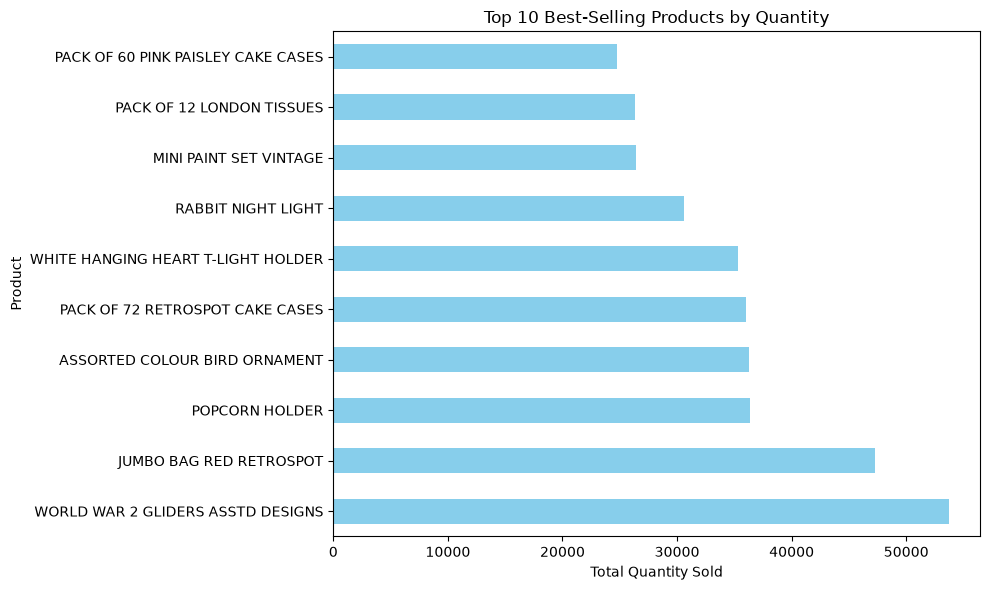

In [5]:
import matplotlib.pyplot as plt

# Chart 1: Top 10 Best-Selling Products
plt.figure(figsize=(10,6))
top_products.plot(kind="barh", color="skyblue")
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

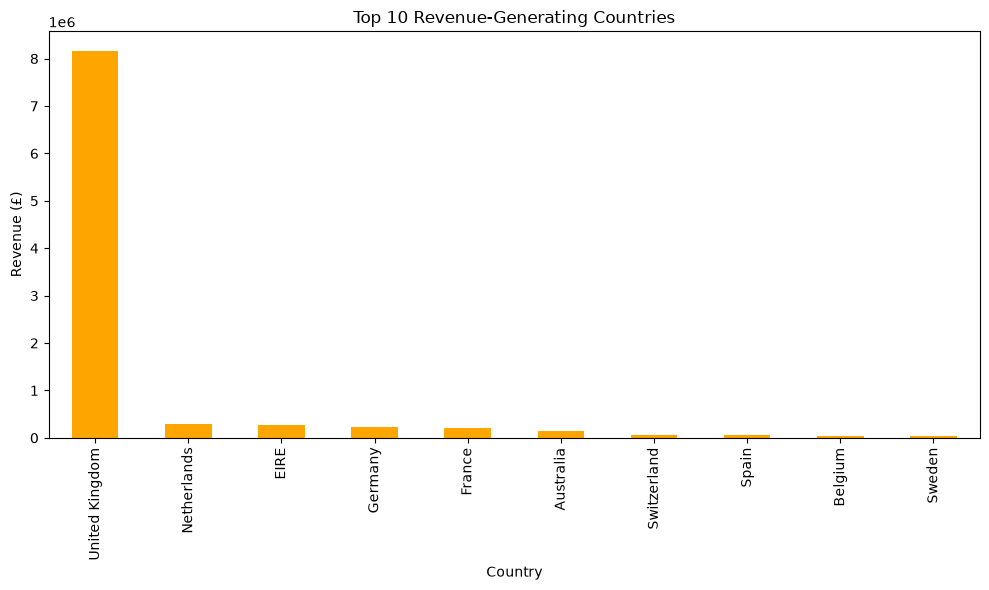

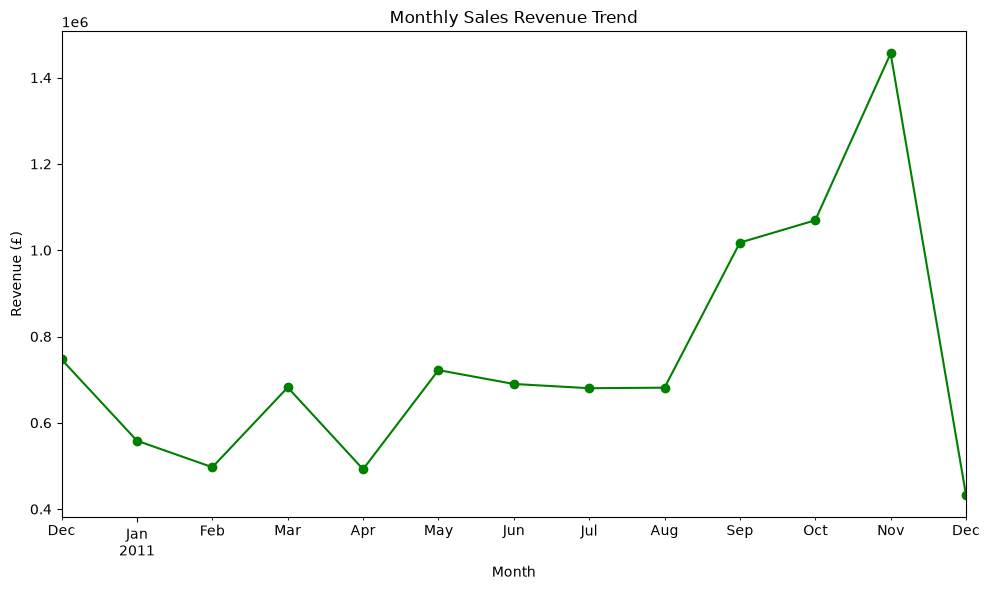

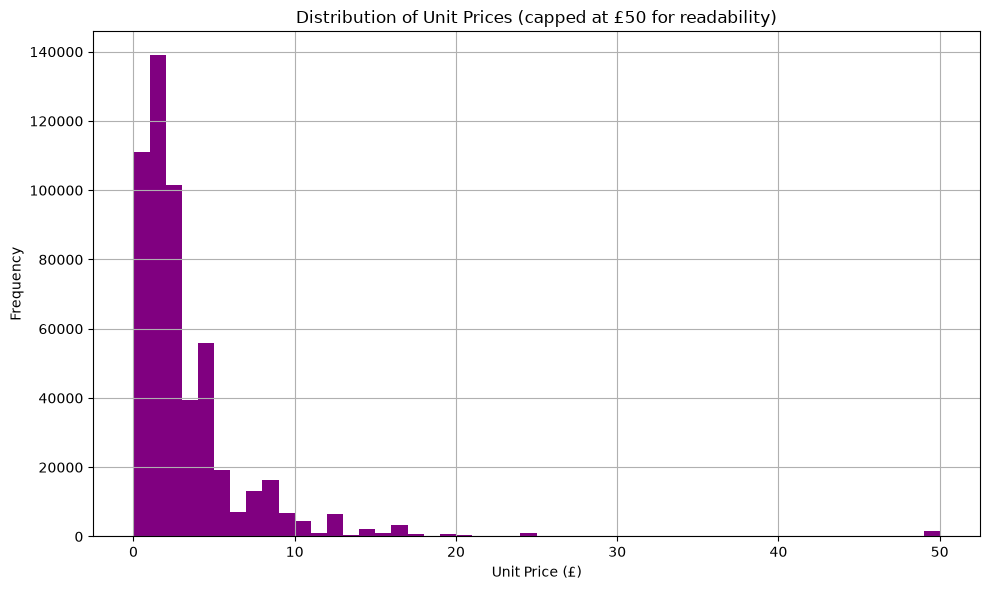

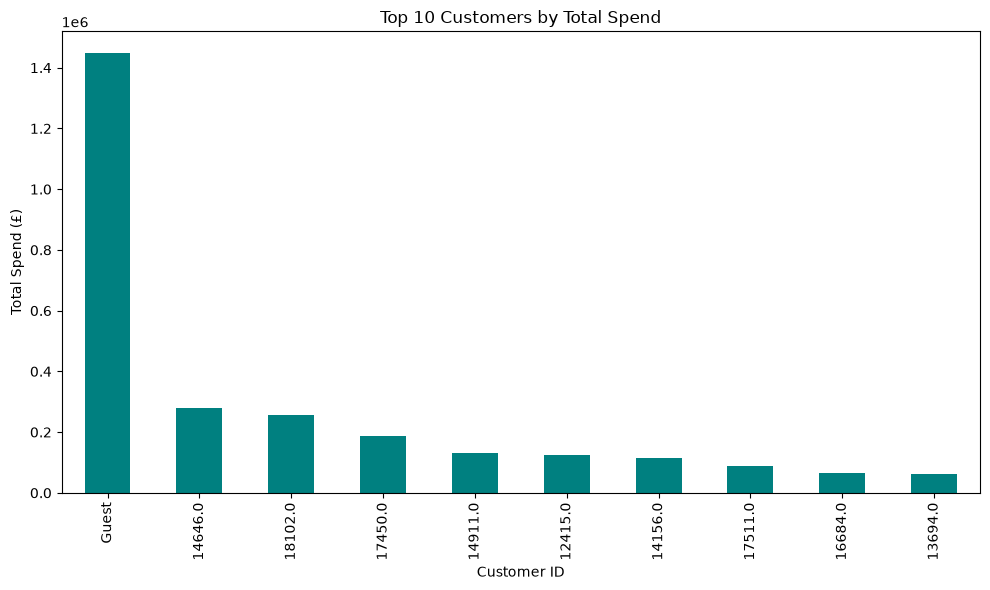

In [6]:
# Chart 2: Top 10 Revenue-Generating Countries
plt.figure(figsize=(10,6))
top_countries.plot(kind="bar", color="orange")
plt.title("Top 10 Revenue-Generating Countries")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

# Chart 3: Monthly Sales Trend
plt.figure(figsize=(10,6))
monthly_sales.plot(kind="line", marker="o", color="green")
plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

# Chart 4: Distribution of Unit Price
plt.figure(figsize=(10,6))
df[df["unitprice"] > 0]["unitprice"].clip(upper=50).hist(bins=50, color="purple")
plt.title("Distribution of Unit Prices (capped at £50 for readability)")
plt.xlabel("Unit Price (£)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Chart 5: Top 10 Customers by Spend
plt.figure(figsize=(10,6))
top_customers.plot(kind="bar", color="teal")
plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend (£)")
plt.tight_layout()
plt.show()

## 5. Insights

1. **Revenue is heavily UK-concentrated:** United Kingdom generated £8.16M, nearly 29× the next highest country (Netherlands, £284K). *(See Chart 2)*

2. **Bulk sellers vs. repeat favorites differ:** "World War 2 Gliders Asstd Designs" leads in total quantity sold (53,751 units), while "White Hanging Heart T-Light Holder" is the most frequently reordered item (2,302 separate orders). *(See Chart 1)*

3. **Clear seasonal peak:** Monthly revenue nearly tripled in November 2011 (£1.46M) versus a typical month (~£680K), consistent with pre-holiday shopping. *(See Chart 3)*

4. **Most unit prices cluster at the low end:** The majority of items are priced under £5, with a long tail of higher-priced products, typical of a high-volume, low-cost retail catalog. *(See Chart 4)*

5. **Guest checkouts are significant:** Unidentified "Guest" transactions collectively totaled £1.4M — more than any single identified customer. *(See Chart 5)*